# Flickr30k Baseline Training

This notebook trains a image-text retrieval baseline with:

- `ResNet50` image encoder
- `BERT-base-uncased` text encoder
- linear projection heads
- symmetric InfoNCE loss
- validation with `Recall@1/10/20`

In [1]:
# Check environment
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no gpu")


2.10.0+cu128
True
NVIDIA A100-SXM4-40GB


In [2]:
!pip install -q datasets transformers pillow tqdm

In [3]:
# Set up the output directory for saving results
from pathlib import Path

USE_DRIVE = False
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUTPUT_DIR = Path('/content/drive/MyDrive/ECE1508/baseline_outputs')
else:
    OUTPUT_DIR = Path('/content/baseline_outputs')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR

PosixPath('/content/baseline_outputs')

In [4]:
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models import ResNet50_Weights, resnet50 #ResNET
from transformers import AutoModel, AutoTokenizer #BERT
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


In [5]:
# Set training hyperparameters and random seed
SEED = 42
BATCH_SIZE = 32
NUM_EPOCHS = 5
LR = 1e-4
WEIGHT_DECAY = 1e-4
PROJECTION_DIM = 256 # Dimension of shared embedding space
MAX_TEXT_LEN = 64 # Maximum number of tokens per text input
TEMPERATURE_INIT = 0.07 # temperature for loss scaling
FREEZE_BACKBONES = True # Whether to freeze pretrained encoders(BERT/ResNet)

random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [6]:
# Load the Flickr30k dataset (image-text pairs)
dataset = load_dataset('Zoe3324/flickr30k-pairs')
dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/657 [00:00<?, ?B/s]

data/train-00000-of-00012.parquet:   0%|          | 0.00/97.0M [00:00<?, ?B/s]

data/train-00001-of-00012.parquet:   0%|          | 0.00/96.2M [00:00<?, ?B/s]

data/train-00002-of-00012.parquet:   0%|          | 0.00/101M [00:00<?, ?B/s]

...

data/test-00000-of-00001.parquet:   0%|          | 0.00/40.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/145000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5070 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'caption', 'split', 'img_id', 'filename'],
        num_rows: 145000
    })
    validation: Dataset({
        features: ['image', 'caption', 'split', 'img_id', 'filename'],
        num_rows: 5070
    })
    test: Dataset({
        features: ['image', 'caption', 'split', 'img_id', 'filename'],
        num_rows: 5000
    })
})

In [7]:
# Split dataset
train_data = dataset['train']
val_data = dataset['validation']
test_data = dataset['test']

print('train:', len(train_data))
print('validation:', len(val_data))
print('test:', len(test_data))

train: 145000
validation: 5070
test: 5000


A group of people stand in the back of a truck filled with cotton.


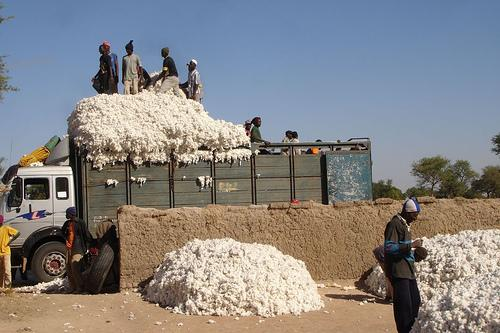

In [8]:
# Inspect a sample from validation set
sample = val_data[0]
print(sample['caption'])
sample['image']

In [9]:
# Define image preprocessing pipeline
image_transform = transforms.Compose([
    transforms.Resize((224, 224)), # standard size for ResNet
    transforms.ToTensor(), # convert PIL image to tensor
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

# Collate function for Dataloader
def collate_fn(batch):
    # Apply image transform and stack into a batch tensor
    images = torch.stack([image_transform(sample['image']) for sample in batch])
    captions = [sample['caption'] for sample in batch]
    # Store image filename for retrieval evaluation
    group_ids = [sample['filename'] for sample in batch]

    # Tokenize text captions into input IDs and attention masks
    tokenized = tokenizer(
        captions,
        return_tensors='pt',
        padding=True,
        truncation=True,
        max_length=MAX_TEXT_LEN,
    )

    # Return a dictionary used as model input
    return {
        'images': images,
        'captions': captions,
        'input_ids': tokenized['input_ids'],
        'attention_mask': tokenized['attention_mask'],
        'group_ids': group_ids,
    }


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [10]:
# Create DataLoader for train, validation, test sets
train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
)

In [11]:
# Define model architecture and training components
# Projection head to map image/text features into a shared embedding space
class ProjectionHead(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, output_dim),
            nn.GELU(),
            nn.Linear(output_dim, output_dim),
        )

    def forward(self, x):
        return self.net(x)

# image encoder: pretrained ResNet50
image_encoder = resnet50(weights=ResNet50_Weights.DEFAULT)
image_encoder.fc = nn.Identity() # remove classification head
image_encoder = image_encoder.to(device)

# text encoder: pretrained BERT
text_encoder = AutoModel.from_pretrained('bert-base-uncased')
text_encoder = text_encoder.to(device)

# Projection heads
image_projection = ProjectionHead(2048, PROJECTION_DIM).to(device)
text_projection = ProjectionHead(768, PROJECTION_DIM).to(device)

# Learnable temperature parameter for contrastive loss scaling
log_temperature = nn.Parameter(torch.log(torch.tensor(1.0 / TEMPERATURE_INIT, device=device)))

# Optionally freeze pretrained encoders to reduce training cost
if FREEZE_BACKBONES:
    for param in image_encoder.parameters():
        param.requires_grad = False
    for param in text_encoder.parameters():
        param.requires_grad = False

# Collect parameters to train
trainable_params = (
    list(image_projection.parameters()) +
    list(text_projection.parameters()) +
    [log_temperature]
)

if not FREEZE_BACKBONES:
    trainable_params += (
        list(image_encoder.parameters()) +
        list(text_encoder.parameters())
    )

# Define optimizer: Adam
optimizer = torch.optim.AdamW(trainable_params, lr=LR, weight_decay=WEIGHT_DECAY)

print('trainable parameter groups ready!')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 144MB/s]


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable parameter groups ready!


In [12]:
# Encode a batch of data into normalized iamge and text embeddings
def encode_batch(batch):
    images = batch['images'].to(device, non_blocking=True)
    input_ids = batch['input_ids'].to(device, non_blocking=True)
    attention_mask = batch['attention_mask'].to(device, non_blocking=True)

    if FREEZE_BACKBONES:
        # Set to evaluation mode - disable dropout, batchnorm...
        image_encoder.eval()
        text_encoder.eval()
        with torch.no_grad():
            image_features = image_encoder(images)
            text_outputs = text_encoder(input_ids=input_ids, attention_mask=attention_mask)
            # use CLS token represent as text embedding
            text_features = text_outputs.last_hidden_state[:, 0, :]
    else:
        # train mode
        image_encoder.train()
        text_encoder.train()
        image_features = image_encoder(images)
        text_outputs = text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        text_features = text_outputs.last_hidden_state[:, 0, :]

    # Project features into shared embedding space
    image_embeds = F.normalize(image_projection(image_features), dim=-1)
    text_embeds = F.normalize(text_projection(text_features), dim=-1)
    return image_embeds, text_embeds


def contrastive_loss(image_embeds, text_embeds):
    # teperature scales similarity scores
    temperature = log_temperature.exp().clamp(min=1e-3, max=100.0)
    # compute similarity matrix between all image-text pairs
    # Shape [batch size, batch size]
    logits = (image_embeds @ text_embeds.T) * temperature
    # Ground truth labels: correct pairs are on the diagonal
    labels = torch.arange(logits.size(0), device=device)
    loss_i2t = F.cross_entropy(logits, labels)
    loss_t2i = F.cross_entropy(logits.T, labels)
    loss = 0.5 * (loss_i2t + loss_t2i)
    return loss, logits

# Compute retrieval performance using Recall @K metrics
@torch.no_grad()
def compute_recall_metrics(image_embeds, text_embeds, group_ids, ks=(1, 10, 20)):
    similarity = text_embeds @ image_embeds.T
    metrics = {}

    group_to_indices = {}
    for idx, group_id in enumerate(group_ids):
        if group_id not in group_to_indices:
            group_to_indices[group_id] = []
        group_to_indices[group_id].append(idx)

    # text-to-image
    ranking_t2i = similarity.argsort(dim=1, descending=True)
    for k in ks:
        hits = []
        for i in range(len(group_ids)):
            correct_indices = set(group_to_indices[group_ids[i]])
            topk = ranking_t2i[i, :k].tolist()
            hit = any(idx in correct_indices for idx in topk)
            hits.append(hit)
        metrics[f"t2i_r@{k}"] = sum(hits) / len(hits)

    # image-to-text
    ranking_i2t = similarity.T.argsort(dim=1, descending=True)
    for k in ks:
        hits = []
        for i in range(len(group_ids)):
            correct_indices = set(group_to_indices[group_ids[i]])
            topk = ranking_i2t[i, :k].tolist()
            hit = any(idx in correct_indices for idx in topk)
            hits.append(hit)
        metrics[f"i2t_r@{k}"] = sum(hits) / len(hits)

    metrics["mean_recall"] = sum(metrics.values()) / len(metrics)
    return metrics

# Evaluate the model on a validation or test split
@torch.no_grad()
def validate(dataloader, split_name='validation'):
    # Switch all model components to evaluation mode
    image_projection.eval()
    text_projection.eval()
    image_encoder.eval()
    text_encoder.eval()

    all_image_embeds = []
    all_text_embeds = []
    all_group_ids = []

    # Iterate over dataLoader and encode each batch
    # Collect image embeddings, text embeddings, and group IDs across batches
    for batch in tqdm(dataloader, desc=f'Validating {split_name}', leave=False):
        image_embeds, text_embeds = encode_batch(batch)
        all_image_embeds.append(image_embeds)
        all_text_embeds.append(text_embeds)
        all_group_ids.extend(batch["group_ids"])

    all_image_embeds = torch.cat(all_image_embeds, dim=0)
    all_text_embeds = torch.cat(all_text_embeds, dim=0)

    # COmpute retrieval metrics
    return compute_recall_metrics(
        all_image_embeds,
        all_text_embeds,
        all_group_ids,
        ks=(1, 10, 20),
    )

In [13]:
# Sanity check: run a single batch through pipeline
batch = next(iter(train_loader))
image_embeds, text_embeds = encode_batch(batch)
loss, logits = contrastive_loss(image_embeds, text_embeds)

print('image_embeds:', image_embeds.shape)
print('text_embeds:', text_embeds.shape)
print('logits:', logits.shape)
print('loss:', loss.item())

image_embeds: torch.Size([32, 256])
text_embeds: torch.Size([32, 256])
logits: torch.Size([32, 32])
loss: 3.5321555137634277


In [14]:
# Full training loop
best_val = -1.0
history = []

for epoch in range(1, NUM_EPOCHS + 1):
    image_projection.train()
    text_projection.train()
    if not FREEZE_BACKBONES:
        image_encoder.train()
        text_encoder.train()

    running_loss = 0.0

    progress = tqdm(train_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS}')

    # batch training
    for batch in progress:
        optimizer.zero_grad(set_to_none=True)

        image_embeds, text_embeds = encode_batch(batch)
        loss, _ = contrastive_loss(image_embeds, text_embeds)

        loss.backward() # backpropagation
        optimizer.step() # update parameters

        running_loss += loss.item() # accumulate batch loss
        progress.set_postfix(loss=f'{loss.item():.4f}')

    avg_train_loss = running_loss / len(train_loader)
    # Evaluate model performance
    val_metrics = validate(val_loader, split_name='validation')
    epoch_log = {'epoch': epoch, 'train_loss': avg_train_loss, **val_metrics}
    history.append(epoch_log)

    print(epoch_log)

    # Save model if validation performance improves
    if val_metrics['mean_recall'] > best_val:
        best_val = val_metrics['mean_recall']
        checkpoint = {
            'epoch': epoch,
            'image_encoder': image_encoder.state_dict(),
            'text_encoder': text_encoder.state_dict(),
            'image_projection': image_projection.state_dict(),
            'text_projection': text_projection.state_dict(),
            'log_temperature': log_temperature.detach().cpu(),
            'val_metrics': val_metrics,
            'config': {
                'projection_dim': PROJECTION_DIM,
                'max_text_len': MAX_TEXT_LEN,
                'freeze_backbones': FREEZE_BACKBONES,
            },
        }
        torch.save(checkpoint, OUTPUT_DIR / 'best_baseline.pt')
        print('saved best checkpoint to', OUTPUT_DIR / 'best_baseline.pt')

history

Epoch 1/5:   0%|          | 0/4532 [00:00<?, ?it/s]

Validating validation:   0%|          | 0/159 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 1.215066852710569, 't2i_r@1': 0.16153846153846155, 't2i_r@10': 0.2512820512820513, 't2i_r@20': 0.36725838264299804, 'i2t_r@1': 0.21499013806706113, 'i2t_r@10': 0.606508875739645, 'i2t_r@20': 0.7406311637080868, 'mean_recall': 0.3903681788297173}
saved best checkpoint to /content/baseline_outputs/best_baseline.pt


Epoch 2/5:   0%|          | 0/4532 [00:00<?, ?it/s]

Validating validation:   0%|          | 0/159 [00:00<?, ?it/s]

...

{'epoch': 4, 'train_loss': 0.5239998279279139, 't2i_r@1': 0.1777120315581854, 't2i_r@10': 0.2794871794871795, 't2i_r@20': 0.40611439842209074, 'i2t_r@1': 0.23175542406311636, 'i2t_r@10': 0.6577909270216963, 'i2t_r@20': 0.7830374753451677, 'mean_recall': 0.42264957264957265}
saved best checkpoint to /content/baseline_outputs/best_baseline.pt


Epoch 5/5:   0%|          | 0/4532 [00:00<?, ?it/s]

Validating validation:   0%|          | 0/159 [00:00<?, ?it/s]

{'epoch': 5, 'train_loss': 0.4406610638614138, 't2i_r@1': 0.17731755424063117, 't2i_r@10': 0.27534516765285993, 't2i_r@20': 0.39250493096646943, 'i2t_r@1': 0.2514792899408284, 'i2t_r@10': 0.645956607495069, 'i2t_r@20': 0.7642998027613412, 'mean_recall': 0.4178172255095332}


[{'epoch': 1,
  'train_loss': 1.215066852710569,
  't2i_r@1': 0.16153846153846155,
  't2i_r@10': 0.2512820512820513,
  't2i_r@20': 0.36725838264299804,
  'i2t_r@1': 0.21499013806706113,
  'i2t_r@10': 0.606508875739645,
  'i2t_r@20': 0.7406311637080868,
  'mean_recall': 0.3903681788297173},
 {'epoch': 2,
  'train_loss': 0.789478947221904,
  't2i_r@1': 0.17928994082840236,
  't2i_r@10': 0.2715976331360947,
  't2i_r@20': 0.385207100591716,
  'i2t_r@1': 0.23372781065088757,
  'i2t_r@10': 0.6538461538461539,
  'i2t_r@20': 0.7810650887573964,
  'mean_recall': 0.4174556213017751},
 {'epoch': 3,
  'train_loss': 0.6343051157069753,
  't2i_r@1': 0.1834319526627219,
  't2i_r@10': 0.27120315581854043,
  't2i_r@20': 0.39861932938856015,
  'i2t_r@1': 0.22781065088757396,
  'i2t_r@10': 0.6587771203155819,
  'i2t_r@20': 0.7781065088757396,
  'mean_recall': 0.41965811965811967},
 {'epoch': 4,
  'train_loss': 0.5239998279279139,
  't2i_r@1': 0.1777120315581854,
  't2i_r@10': 0.2794871794871795,
  't2i_r

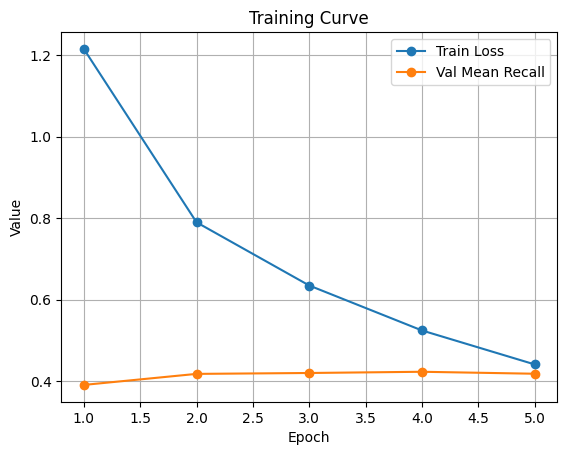

In [15]:
# Training Loss figure
import matplotlib.pyplot as plt

epochs = [h['epoch'] for h in history]
train_loss = [h['train_loss'] for h in history]
val_recall = [h['mean_recall'] for h in history]

plt.figure()
plt.plot(epochs, train_loss, marker='o', label='Train Loss')
plt.plot(epochs, val_recall, marker='o', label='Val Mean Recall')

plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Training Curve')
plt.legend()
plt.grid(True)
plt.show()

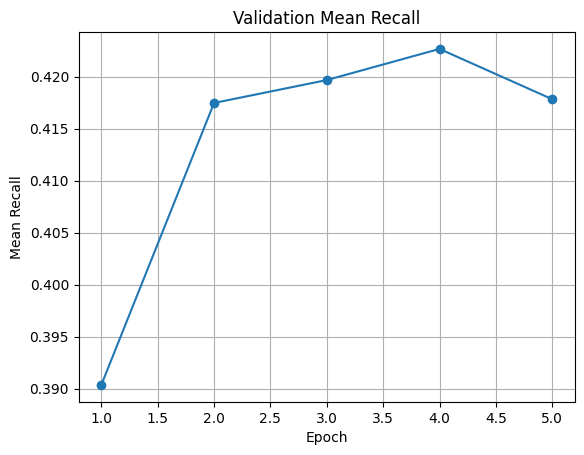

In [16]:
# Validation Mean Recall
val_recall = [h['mean_recall'] for h in history]

plt.figure()
plt.plot(epochs, val_recall, marker='o')
plt.title('Validation Mean Recall')
plt.xlabel('Epoch')
plt.ylabel('Mean Recall')
plt.grid(True)
plt.show()

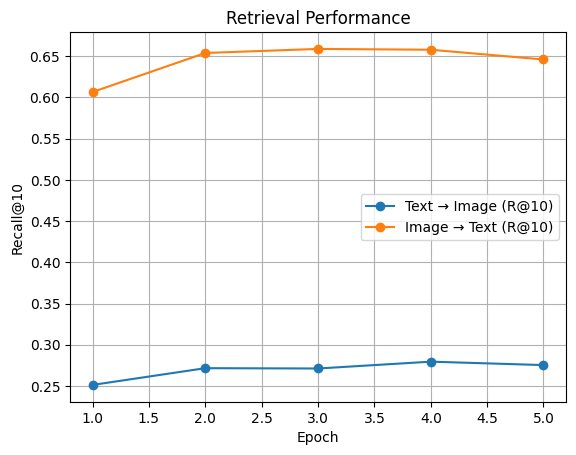

In [17]:
# t2i vs i2t
t2i = [h['t2i_r@10'] for h in history]
i2t = [h['i2t_r@10'] for h in history]

plt.figure()
plt.plot(epochs, t2i, marker='o', label='Text → Image (R@10)')
plt.plot(epochs, i2t, marker='o', label='Image → Text (R@10)')

plt.title('Retrieval Performance')
plt.xlabel('Epoch')
plt.ylabel('Recall@10')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
!pip install -q huggingface_hub

from huggingface_hub import login, HfApi
login()

api = HfApi()
repo_id = "Zoe3324/flickr30k-baseline"
hf_model_tag = "gelu_freeze_proj256_bs32_lr1e-4_epoch5"
hf_filename = f"best_baseline_{hf_model_tag}.pt" if hf_model_tag else "best_baseline.pt"
api.create_repo(repo_id=repo_id, repo_type="model", exist_ok=True)

api.upload_file(
    path_or_fileobj=str(OUTPUT_DIR / "best_baseline.pt"),
    path_in_repo=hf_filename,
    repo_id=repo_id,
    repo_type="model",
)

print(f"uploaded to {repo_id}/{hf_filename}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ..._outputs/best_baseline.pt:   0%|          |  557kB /  536MB            

uploaded to Zoe3324/flickr30k-baseline/best_baseline_gelu_freeze_proj256_bs32_lr1e-4_epoch5.pt


In [20]:
# Load best saved model checkpoint and evaluate
from huggingface_hub import hf_hub_download
import torch

repo_id = "Zoe3324/flickr30k-baseline"
hf_model_tag = "gelu_freeze_proj256_bs32_lr1e-4_epoch5"
hf_filename = f"best_baseline_{hf_model_tag}.pt" if hf_model_tag else "best_baseline.pt"

ckpt_path = hf_hub_download(
    repo_id=repo_id,
    filename=hf_filename,
    repo_type="model",
)

best_checkpoint = torch.load(ckpt_path, map_location=device)

# Restore model weights
image_encoder.load_state_dict(best_checkpoint["image_encoder"])
text_encoder.load_state_dict(best_checkpoint["text_encoder"])
image_projection.load_state_dict(best_checkpoint["image_projection"])
text_projection.load_state_dict(best_checkpoint["text_projection"])
# Restore learned temperature parameter
log_temperature.data = best_checkpoint["log_temperature"].to(device)

# Evaluate on test set
test_metrics = validate(test_loader, split_name="test")
print(test_metrics)

best_baseline_gelu_freeze_proj256_bs32_l(…):   0%|          | 0.00/536M [00:00<?, ?B/s]

Validating test:   0%|          | 0/157 [00:00<?, ?it/s]

{'t2i_r@1': 0.199, 't2i_r@10': 0.3112, 't2i_r@20': 0.434, 'i2t_r@1': 0.256, 'i2t_r@10': 0.698, 'i2t_r@20': 0.8, 'mean_recall': 0.4497}
